<a href="https://colab.research.google.com/github/sonalisanjeevprabu18/Neural-Network-and-Deep-Learning/blob/main/skin_lesion_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle -q
import os, shutil, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print('TensorFlow version:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os, json

os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_creds = {
    "username": "sonalisanjeevprabu",   # ← your Kaggle username
    "key": "KGAT_fbf91714906c56447a049bbdc86b7f99"       # ← paste your token here
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Kaggle API key configured!')

Kaggle API key configured!


In [3]:
# Download the HAM10000 dataset
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content/skin_data
print('Download complete!')

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:27<00:00, 203MB/s]

Download complete!


In [4]:
# Unzip
data_path = '/content/skin_data'

for fname in os.listdir(data_path):
    if fname.endswith('.zip'):
        zip_path = os.path.join(data_path, fname)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(data_path)
        print(f'Extracted: {fname}')

# Show what we have
for root, dirs, files_list in os.walk(data_path):
    level = root.replace(data_path, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        for f in files_list[:5]:
            print(f'{indent}  {f}')

Extracted: skin-cancer-mnist-ham10000.zip
skin_data/
  hmnist_8_8_L.csv
  hmnist_28_28_L.csv
  skin-cancer-mnist-ham10000.zip
  hmnist_8_8_RGB.csv
  hmnist_28_28_RGB.csv
  ham10000_images_part_2/
    ISIC_0032300.jpg
    ISIC_0030253.jpg
    ISIC_0030966.jpg
    ISIC_0030511.jpg
    ISIC_0030498.jpg
  HAM10000_images_part_1/
    ISIC_0026015.jpg
    ISIC_0025186.jpg
    ISIC_0026918.jpg
    ISIC_0029045.jpg
    ISIC_0025997.jpg
  ham10000_images_part_1/
    ISIC_0026015.jpg
    ISIC_0025186.jpg
    ISIC_0026918.jpg
    ISIC_0029045.jpg
    ISIC_0025997.jpg
  HAM10000_images_part_2/
    ISIC_0032300.jpg
    ISIC_0030253.jpg
    ISIC_0030966.jpg
    ISIC_0030511.jpg
    ISIC_0030498.jpg


In [5]:
# Load metadata CSV
csv_path = None
for root, dirs, files_list in os.walk(data_path):
    for f in files_list:
        if 'metadata' in f.lower() or 'ham10000_metadata' in f.lower():
            csv_path = os.path.join(root, f)
            break
    if csv_path:
        break

# Try common name if not found
if csv_path is None:
    for root, dirs, files_list in os.walk(data_path):
        for f in files_list:
            if f.endswith('.csv'):
                csv_path = os.path.join(root, f)
                break

print('CSV found at:', csv_path)
df = pd.read_csv(csv_path)
print(df.head())
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nClass distribution:')
print(df['dx'].value_counts())

CSV found at: /content/skin_data/HAM10000_metadata.csv
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
Shape: (10015, 7)

Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


Binary Label Distribution:
label
benign       8061
malignant    1954
Name: count, dtype: int64


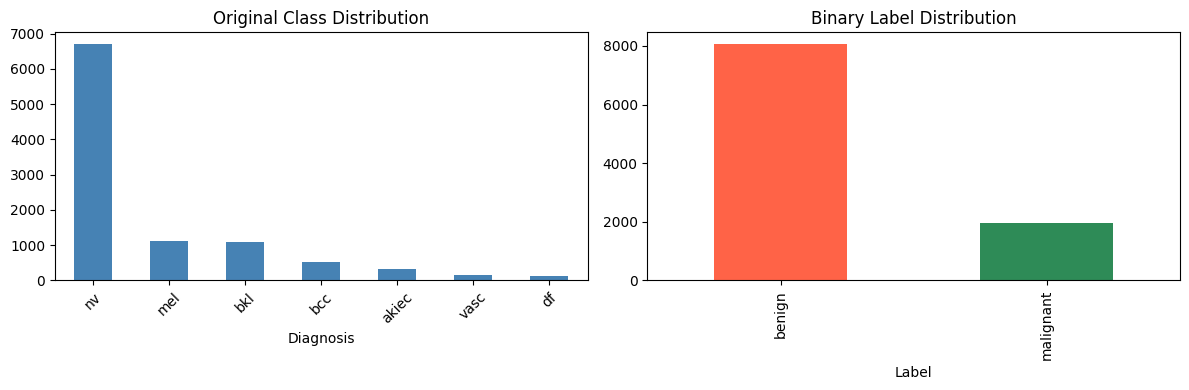

In [6]:
# === BINARY CLASSIFICATION ===
# Benign: nv (melanocytic nevi), bkl (benign keratosis), df (dermatofibroma), vasc
# Malignant: mel (melanoma), bcc (basal cell carcinoma), akiec (actinic keratosis)

BENIGN_CLASSES  = ['nv', 'bkl', 'df', 'vasc']
MALIGNANT_CLASSES = ['mel', 'bcc', 'akiec']

df['label'] = df['dx'].apply(
    lambda x: 'malignant' if x in MALIGNANT_CLASSES else 'benign'
)

print('Binary Label Distribution:')
print(df['label'].value_counts())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['dx'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Original Class Distribution')
axes[0].set_xlabel('Diagnosis')
axes[0].tick_params(axis='x', rotation=45)

df['label'].value_counts().plot(kind='bar', ax=axes[1], color=['tomato', 'seagreen'])
axes[1].set_title('Binary Label Distribution')
axes[1].set_xlabel('Label')
plt.tight_layout()
plt.show()

In [7]:
# Find all image files
image_path_dict = {}
for root, dirs, files_list in os.walk(data_path):
    for f in files_list:
        if f.endswith('.jpg') or f.endswith('.jpeg'):
            img_id = f.replace('.jpg', '').replace('.jpeg', '')
            image_path_dict[img_id] = os.path.join(root, f)

print(f'Total images found: {len(image_path_dict)}')

# Map image paths to dataframe
df['image_path'] = df['image_id'].map(image_path_dict)
df = df.dropna(subset=['image_path'])
print(f'Images matched: {len(df)}')
df.head()

Total images found: 10015
Images matched: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization,label,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,benign,/content/skin_data/ham10000_images_part_1/ISIC...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,benign,/content/skin_data/ham10000_images_part_1/ISIC...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,benign,/content/skin_data/ham10000_images_part_1/ISIC...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,benign,/content/skin_data/ham10000_images_part_1/ISIC...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,benign,/content/skin_data/HAM10000_images_part_2/ISIC...


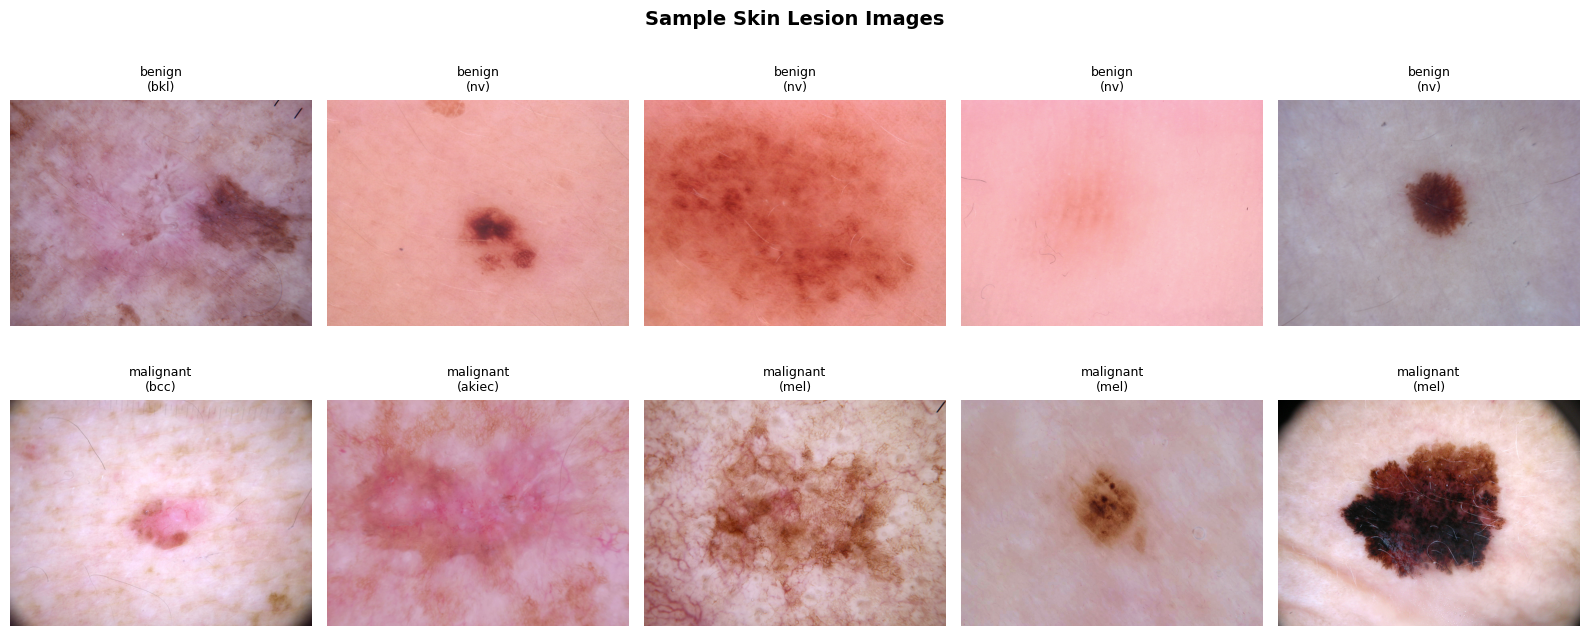

In [8]:
# Visualize sample images
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for i, label in enumerate(['benign', 'malignant']):
    samples = df[df['label'] == label].sample(5, random_state=42)
    for j, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row['image_path'])
        axes[i][j].imshow(img)
        axes[i][j].set_title(f"{label}\n({row['dx']})", fontsize=9)
        axes[i][j].axis('off')
plt.suptitle('Sample Skin Lesion Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5: Train/Val/Test Split + ImageDataGenerator

In [9]:
# Subsample for faster training on free Colab (optional: remove for full dataset)
# Taking 2000 samples balanced — you can increase this
benign_df = df[df['label'] == 'benign'].sample(1000, random_state=42)
malignant_df = df[df['label'] == 'malignant'].sample(1000, random_state=42)
df_balanced = pd.concat([benign_df, malignant_df]).reset_index(drop=True)
print('Balanced dataset size:', len(df_balanced))

# Train / Val / Test split
train_df, temp_df = train_test_split(df_balanced, test_size=0.3, stratify=df_balanced['label'], random_state=42)
val_df, test_df   = train_test_split(temp_df,     test_size=0.5, stratify=temp_df['label'],     random_state=42)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Balanced dataset size: 2000
Train: 1400 | Val: 300 | Test: 300


In [10]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

# Data Augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2]
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

def make_generator(datagen, df_split, shuffle=True):
    return datagen.flow_from_dataframe(
        dataframe=df_split,
        x_col='image_path',
        y_col='label',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=shuffle
    )

train_gen = make_generator(train_datagen, train_df, shuffle=True)
val_gen   = make_generator(val_test_datagen, val_df, shuffle=False)
test_gen  = make_generator(val_test_datagen, test_df, shuffle=False)

print('Class indices:', train_gen.class_indices)

Found 1400 validated image filenames belonging to 2 classes.
Found 300 validated image filenames belonging to 2 classes.
Found 300 validated image filenames belonging to 2 classes.
Class indices: {'benign': 0, 'malignant': 1}


## Step 6: Build Model (MobileNetV2 Transfer Learning)

In [11]:
def build_model():
    # Load MobileNetV2 pretrained on ImageNet (without top)
    base_model = MobileNetV2(
        input_shape=(128, 128, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Freeze base initially

    # Build classifier on top
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')  # Binary output
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model, base_model

model, base_model = build_model()
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,435,393 (9.29 MB)

 Trainable params: 174,849 (683.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

## Step 7: Phase 1 Training (Frozen Base)

In [12]:
callbacks = [
    EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print('=== Phase 1: Training classifier head (base frozen) ===')
history1 = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

=== Phase 1: Training classifier head (base frozen) ===
Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.6800 - auc: 0.7456 - loss: 0.6632 - val_accuracy: 0.7567 - val_auc: 0.8469 - val_loss: 0.4851 - learning_rate: 0.0010
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 369ms/step - accuracy: 0.7100 - auc: 0.7926 - loss: 0.5833 - val_accuracy: 0.7567 - val_auc: 0.8475 - val_loss: 0.4872 - learning_rate: 0.0010
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 361ms/step - accuracy: 0.7400 - auc: 0.8230 - loss: 0.5189 - val_accuracy: 0.7900 - val_auc: 0.8727 - val_loss: 0.4550 - learning_rate: 0.0010
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 359ms/step - accuracy: 0.7429 - auc: 0.8211 - loss: 0.5363 - val_accuracy: 0.7867 - val_auc: 0.8787 - val_loss: 0.4420 - learning_rate: 0.0010
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 17s 383ms/step - accuracy: 0.7571 - auc: 0.8285 - loss: 0.5153 - val_accuracy: 0.7600 - val_auc: 0.8652 - val_loss: 0.4624 - learning_rate: 0.0010
Epoch 6/15
44/44 ━━━━━

## Step 8: Phase 2 — Fine-Tuning (Unfreeze top layers)

In [13]:
# Unfreeze last 30 layers of base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print(f'Trainable layers: {sum(1 for l in model.layers if l.trainable)}')
print('=== Phase 2: Fine-tuning ===')

history2 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

Trainable layers: 8
=== Phase 2: Fine-tuning ===
Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 53s 780ms/step - accuracy: 0.7157 - auc: 0.7931 - loss: 0.5576 - val_accuracy: 0.7933 - val_auc: 0.8877 - val_loss: 0.4384 - learning_rate: 1.0000e-05
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 363ms/step - accuracy: 0.7279 - auc: 0.7946 - loss: 0.5610 - val_accuracy: 0.7800 - val_auc: 0.8853 - val_loss: 0.4544 - learning_rate: 1.0000e-05
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.7218 - auc: 0.7993 - loss: 0.5494
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
44/44 ━━━━━━━━━━━━━━━━━━━━ 17s 379ms/step - accuracy: 0.7179 - auc: 0.8001 - loss: 0.5483 - val_accuracy: 0.7833 - val_auc: 0.8845 - val_loss: 0.4727 - learning_rate: 1.0000e-05
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 367ms/step - accuracy: 0.7343 - auc: 0.8233 - loss: 0.5190 - val_accuracy: 0.7767 - val_auc: 0.8848 - val_loss: 0.4845 - learning_rate: 5.0000e-06
Epoch 5/10
44/44 ━━━━━━━━━━━━━

## Step 9: Plot Training History

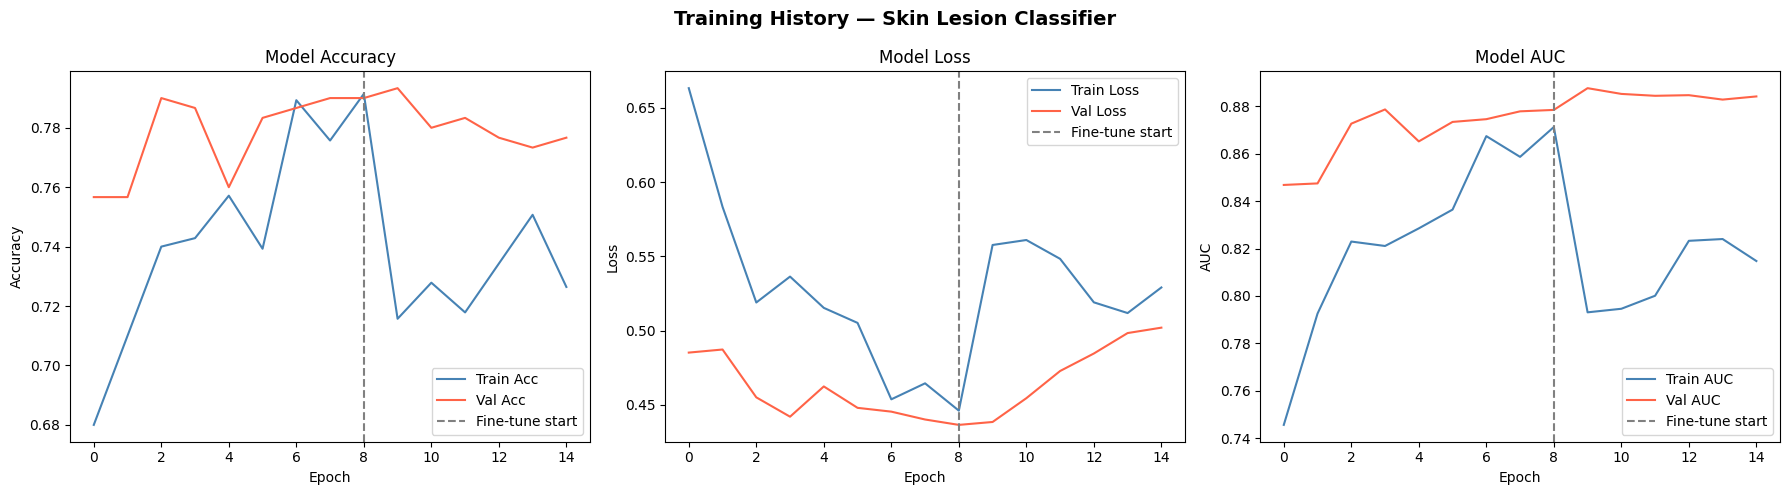

In [14]:
def combine_history(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

history = combine_history(history1, history2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
axes[0].plot(history['accuracy'],     label='Train Acc',  color='steelblue')
axes[0].plot(history['val_accuracy'], label='Val Acc',    color='tomato')
axes[0].axvline(len(history1.history['accuracy'])-1, color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history['loss'],     label='Train Loss', color='steelblue')
axes[1].plot(history['val_loss'], label='Val Loss',   color='tomato')
axes[1].axvline(len(history1.history['loss'])-1, color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend()

# AUC
axes[2].plot(history['auc'],     label='Train AUC', color='steelblue')
axes[2].plot(history['val_auc'], label='Val AUC',   color='tomato')
axes[2].axvline(len(history1.history['auc'])-1, color='gray', linestyle='--', label='Fine-tune start')
axes[2].set_title('Model AUC')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('AUC')
axes[2].legend()

plt.suptitle('Training History — Skin Lesion Classifier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 10: Evaluate on Test Set

In [15]:
# Evaluate
print('=== Test Set Evaluation ===')
test_loss, test_acc, test_auc = model.evaluate(test_gen, verbose=0)
print(f'Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Test AUC      : {test_auc:.4f}')
print(f'Test Loss     : {test_loss:.4f}')

=== Test Set Evaluation ===
Test Accuracy : 0.7833 (78.33%)
Test AUC      : 0.8636
Test Loss     : 0.4542



Classification Report:
              precision    recall  f1-score   support

      benign       0.81      0.73      0.77       150
   malignant       0.76      0.83      0.79       150

    accuracy                           0.78       300
   macro avg       0.79      0.78      0.78       300
weighted avg       0.79      0.78      0.78       300



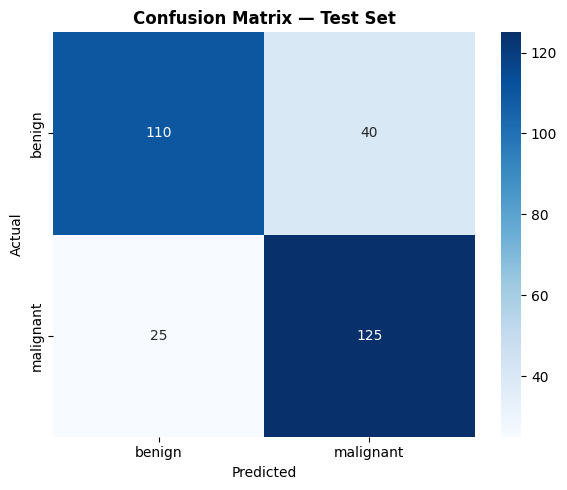

In [16]:
# Predictions
test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=0).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
y_true = test_gen.classes

class_names = list(test_gen.class_indices.keys())  # ['benign', 'malignant']

# Classification Report
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Test Set', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Step 11: Visualize Predictions

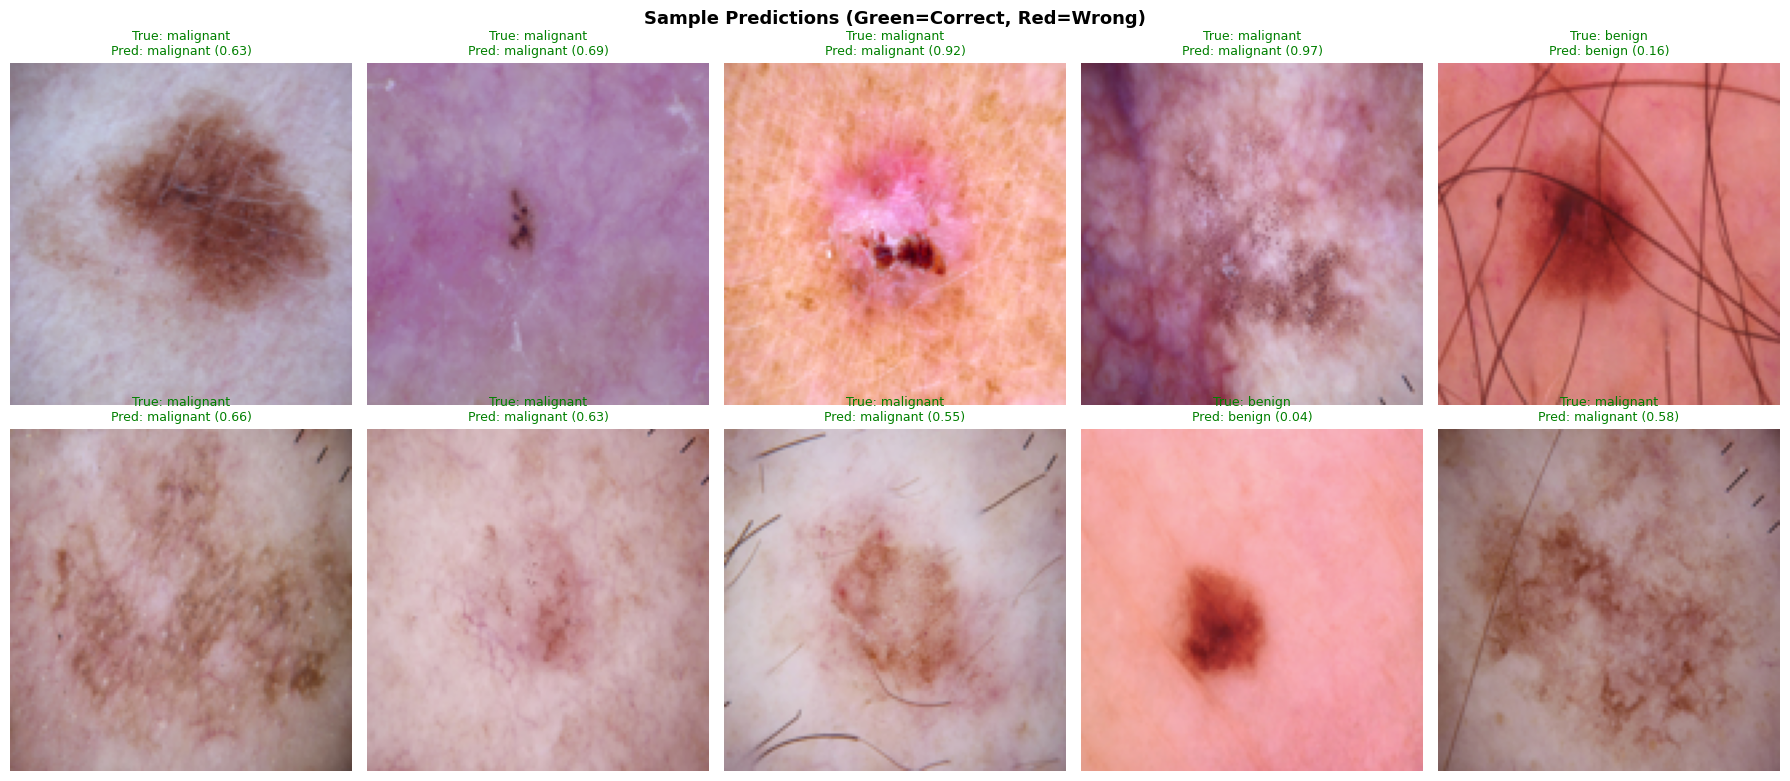

In [17]:
from PIL import Image as PILImage
import numpy as np

# Show 10 random test predictions
test_df_reset = test_df.reset_index(drop=True)
sample_indices = np.random.choice(len(test_df_reset), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    row = test_df_reset.iloc[idx]
    img = PILImage.open(row['image_path']).resize((128, 128))
    img_array = np.array(img) / 255.0
    pred_prob = model.predict(img_array[np.newaxis, ...], verbose=0)[0][0]
    pred_label = 'malignant' if pred_prob > 0.5 else 'benign'
    true_label = row['label']
    correct = pred_label == true_label

    axes[i].imshow(img)
    color = 'green' if correct else 'red'
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label} ({pred_prob:.2f})",
        color=color, fontsize=9
    )
    axes[i].axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 12: Save the Model

In [18]:
model.save('/content/skin_lesion_classifier.h5')
print('Model saved to /content/skin_lesion_classifier.h5')

# Download the model
from google.colab import files
files.download('/content/skin_lesion_classifier.h5')

Model saved to /content/skin_lesion_classifier.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>